In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Cell 1 — Import libraries**

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

# **Cell 2 — Upload & Load the dataset**

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Assignment -Logistic Regression/bank-data/bank-full.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Assignment -Logistic Regression/bank-data/bank-full.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# **Cell 3 — Explore the data**

In [6]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


# **Cell 4 — Check the target variable**

In [8]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


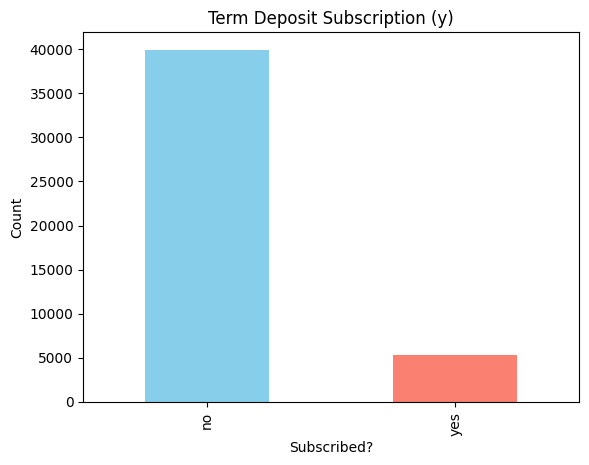

In [9]:
df['y'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title("Term Deposit Subscription (y)")
plt.xlabel("Subscribed?")
plt.ylabel("Count")
plt.show()

# **Cell 5 — Convert target to numbers**

In [10]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})
df['y'].head()

,y
0,0
1,0
2,0
3,0
4,0


# **Cell 6 — Handle categorical (text) columns**

In [11]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing',
                     'loan', 'contact', 'month', 'poutcome']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()

,age,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,0,False,True,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,0,True,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True


# **Cell 7 — Define features (X) and target (y)**

In [12]:
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

print("Number of features:", X.shape[1])

Number of features: 42


# **Cell 8 — Train-Test-Split**

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 36168
Testing samples: 9043


# **Cell 9 — Build and train the model**

In [14]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

# **Cell 10 — Make predictions**

In [16]:
y_predicted = model.predict(X_test)
y_predicted[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# **Cell 11 — Check accuracy**

In [17]:
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 89.88%


# **Cell 12 — Confusion matrix & detailed report**

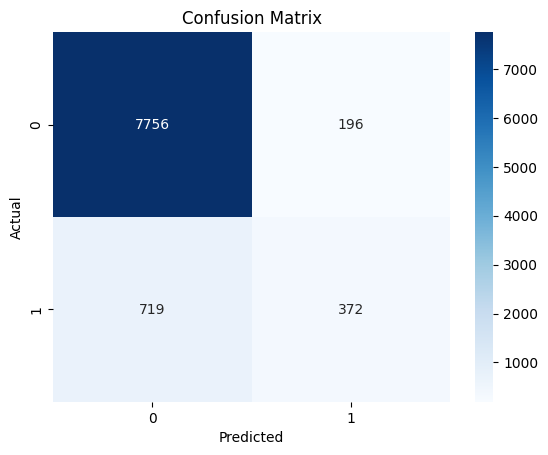

              precision    recall  f1-score   support

           0       0.92      0.98      0.94      7952
           1       0.65      0.34      0.45      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.66      0.70      9043
weighted avg       0.88      0.90      0.88      9043



In [18]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_predicted)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_predicted))

# **Cell 13 — Predict probability for a sample customer**

In [19]:
sample = X_test.iloc[[547]]
probability = model.predict_proba(sample)
print("Probability [No, Yes]:", probability)
print("Actual value:", y_test.iloc[0])

Probability [No, Yes]: [[0.97262262 0.02737738]]
Actual value: 0


# **Random Predictions**

      RANDOM CUSTOMER PREDICTION (Index #3982)
Actual Status    : No (Not Subscribed)
Predicted Status : No (Not Subscribed)
---------------------------------------------
Confidence (No)  : 97.53%
Confidence (Yes) : 2.47%


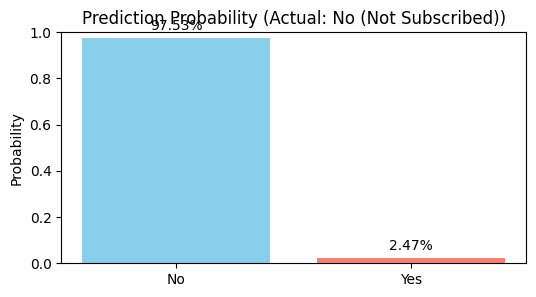

In [20]:
import numpy as np

random_idx = np.random.randint(0, len(X_test))

sample_features = X_test.iloc[[random_idx]]
actual_label = "Yes (Subscribed)" if y_test.iloc[random_idx] == 1 else "No (Not Subscribed)"

predicted_class = model.predict(sample_features)[0]
predicted_label = "Yes (Subscribed)" if predicted_class == 1 else "No (Not Subscribed)"
probs = model.predict_proba(sample_features)[0]

print("=" * 45)
print(f"      RANDOM CUSTOMER PREDICTION (Index #{random_idx})")
print("=" * 45)
print(f"Actual Status    : {actual_label}")
print(f"Predicted Status : {predicted_label}")
print("-" * 45)
print(f"Confidence (No)  : {probs[0]:.2%}")
print(f"Confidence (Yes) : {probs[1]:.2%}")
print("=" * 45)

plt.figure(figsize=(6, 3))
bars = plt.bar(['No', 'Yes'], probs, color=['skyblue', 'salmon'])
plt.title(f"Prediction Probability (Actual: {actual_label})")
plt.ylabel("Probability")
plt.ylim(0, 1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2%}", ha='center', va='bottom')

plt.show()